In [1]:
import pandas as pd
from pathlib import Path

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

In [2]:
project_root = Path.cwd().parents[1]

bronze_path = project_root / ".." / "data" / "bronze" / "2017-bronze_burvot_t1_rhone_69.csv"
silver_bureau_path = project_root / ".." / "data" / "silver" / "2017_silver_burvot_t1_rhone_69_bureau.csv"
silver_candidate_path = project_root / ".." / "data" / "silver" / "2017_silver_burvot_t1_rhone_69_candidate.csv"

print(f"Bronze path: {bronze_path}")

# Read bronze
df_bronze = pd.read_csv(bronze_path, sep=";", dtype=str, encoding="utf-8")
df_bronze.columns = [c.strip() for c in df_bronze.columns]

Bronze path: /Users/zainfrayha/Documents/EPSI/MSPR/electio-analytics-poc/src/../data/bronze/2017-bronze_burvot_t1_rhone_69.csv


In [3]:
# Keep code columns as strings to preserve leading zeros
base_dtypes = {
    "Code du département": "string",
    "Libellé du département": "string",
    "Code de la circonscription": "string",
    "Libellé de la circonscription": "string",
    "Code de la commune": "string",
    "Libellé de la commune": "string",
    "Code du b.vote": "string",   # identifier, not a measure
    "Inscrits": "Int64",
    "Abstentions": "Int64",
    "% Abs/Ins": "Float64",
    "Votants": "Int64",
    "% Vot/Ins": "Float64",
    "Blancs": "Int64",
    "% Blancs/Ins": "Float64",
    "% Blancs/Vot": "Float64",
    "Nuls": "Int64",
    "% Nuls/Ins": "Float64",
    "% Nuls/Vot": "Float64",
    "Exprimés": "Int64",
    "% Exp/Ins": "Float64",
    "% Exp/Vot": "Float64",
}

# Candidate columns repeat with suffixes: '', '.1', '.2', ..., '.11'
candidate_dtypes = {}
for suffix in [""] + [f".{i}" for i in range(1, 12)]:
    candidate_dtypes.update({
        f"N°Panneau{suffix}": "Int64",
        f"Sexe{suffix}": "string",
        f"Nom{suffix}": "string",
        f"Prénom{suffix}": "string",
        f"Voix{suffix}": "Int64",
        f"% Voix/Ins{suffix}": "Float64",
        f"% Voix/Exp{suffix}": "Float64",
    })

meta_dtypes = {
    "extraction_source_url": "string",
    "ingestion_timestamp": "string",
    "source_file_name": "string",
}

dtype_map = {**base_dtypes, **candidate_dtypes, **meta_dtypes}

df = df_bronze.copy()

for col, dtype in dtype_map.items():
    if col not in df.columns:
        continue

    if dtype in {"Int64", "Float64"}:
        df[col] = pd.to_numeric(
            df[col].astype("string").str.replace(",", ".", regex=False),
            errors="coerce",
        ).astype(dtype)
    else:
        df[col] = df[col].astype(dtype).str.strip()

# Remove trailing ".0" from bureau code (artifact of float parsing in source)
df["Code du b.vote"] = df["Code du b.vote"].str.replace(r"\.0$", "", regex=True)

In [4]:
bureau_cols = [
    "Code du département",
    "Libellé du département",
    "Code de la circonscription",
    "Libellé de la circonscription",
    "Code de la commune",
    "Libellé de la commune",
    "Code du b.vote",
    "Inscrits",
    "Abstentions",
    "% Abs/Ins",
    "Votants",
    "% Vot/Ins",
    "Blancs",
    "% Blancs/Ins",
    "% Blancs/Vot",
    "Nuls",
    "% Nuls/Ins",
    "% Nuls/Vot",
    "Exprimés",
    "% Exp/Ins",
    "% Exp/Vot",
    "extraction_source_url",
    "ingestion_timestamp",
    "source_file_name",
]

df_bureau = df[bureau_cols].copy()

df_bureau.insert(0, "bureau_id", (
    df_bureau["Code du département"].fillna("")
    + "_" + df_bureau["Code de la circonscription"].fillna("")
    + "_" + df_bureau["Code de la commune"].fillna("")
    + "_" + df_bureau["Code du b.vote"].fillna("")
))

df_bureau = df_bureau.drop_duplicates(subset=["bureau_id"]).reset_index(drop=True)

print("Bureau shape:", df_bureau.shape)
display(df_bureau.head())

Bureau shape: (1287, 25)


,bureau_id,Code du département,Libellé du département,Code de la circonscription,Libellé de la circonscription,Code de la commune,Libellé de la commune,Code du b.vote,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,% Blancs/Ins,% Blancs/Vot,Nuls,% Nuls/Ins,% Nuls/Vot,Exprimés,% Exp/Ins,% Exp/Vot,extraction_source_url,ingestion_timestamp,source_file_name
0,69_08_001_0001,69,Rhône,08,8ème circonscription,001,Affoux,0001,259,29,11.2,230,88.8,0,0.0,0.0,3,1.16,1.3,227,87.64,98.7,https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
1,69_09_002_0001,69,Rhône,09,9ème circonscription,002,Aigueperse,0001,224,47,20.98,177,79.02,4,1.79,2.26,3,1.34,1.69,170,75.89,96.05,https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
2,69_05_003_0001,69,Rhône,05,5ème circonscription,003,Albigny-sur-Saône,0001,884,155,17.53,729,82.47,15,1.7,2.06,1,0.11,0.14,713,80.66,97.81,https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
3,69_05_003_0002,69,Rhône,05,5ème circonscription,003,Albigny-sur-Saône,0002,781,162,20.74,619,79.26,9,1.15,1.45,3,0.38,0.48,607,77.72,98.06,https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
4,69_09_004_0001,69,Rhône,09,9ème circonscription,004,Alix,0001,455,82,18.02,373,81.98,11,2.42,2.95,2,0.44,0.54,360,79.12,96.51,https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt


In [5]:
print("Colonnes disponibles dans df:")
print(df.columns.tolist())

Colonnes disponibles dans df:
['Code du département', 'Libellé du département', 'Code de la circonscription', 'Libellé de la circonscription', 'Code de la commune', 'Libellé de la commune', 'Code du b.vote', 'Inscrits', 'Abstentions', '% Abs/Ins', 'Votants', '% Vot/Ins', 'Blancs', '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot', 'Exprimés', '% Exp/Ins', '% Exp/Vot', 'N°Panneau_1', 'Sexe_1', 'Nom_1', 'Prénom_1', 'Voix_1', '% Voix/Ins_1', '% Voix/Exp_1', 'N°Panneau_2', 'Sexe_2', 'Nom_2', 'Prénom_2', 'Voix_2', '% Voix/Ins_2', '% Voix/Exp_2', 'N°Panneau_3', 'Sexe_3', 'Nom_3', 'Prénom_3', 'Voix_3', '% Voix/Ins_3', '% Voix/Exp_3', 'N°Panneau_4', 'Sexe_4', 'Nom_4', 'Prénom_4', 'Voix_4', '% Voix/Ins_4', '% Voix/Exp_4', 'N°Panneau_5', 'Sexe_5', 'Nom_5', 'Prénom_5', 'Voix_5', '% Voix/Ins_5', '% Voix/Exp_5', 'N°Panneau_6', 'Sexe_6', 'Nom_6', 'Prénom_6', 'Voix_6', '% Voix/Ins_6', '% Voix/Exp_6', 'N°Panneau_7', 'Sexe_7', 'Nom_7', 'Prénom_7', 'Voix_7', '% Voix/Ins_7', '% Voix/Exp_

In [6]:
candidate_rows = []

# 11 candidate groups: '_1', '_2', ..., '_11'
for suffix in [f"_{i}" for i in range(1, 12)]:
    cols_needed = [
        f"N°Panneau{suffix}", f"Sexe{suffix}", f"Nom{suffix}",
        f"Prénom{suffix}", f"Voix{suffix}", f"% Voix/Ins{suffix}", f"% Voix/Exp{suffix}",
    ]
    if not all(c in df.columns for c in cols_needed):
        continue

    temp = pd.DataFrame({
        "bureau_id": (
            df["Code du département"].fillna("").astype("string")
            + "_" + df["Code de la circonscription"].fillna("").astype("string")
            + "_" + df["Code de la commune"].fillna("").astype("string")
            + "_" + df["Code du b.vote"].fillna("").astype("string")
        ),
        "numero_panneau": df[f"N°Panneau{suffix}"],
        "sexe": df[f"Sexe{suffix}"],
        "nom": df[f"Nom{suffix}"],
        "prenom": df[f"Prénom{suffix}"],
        "voix": df[f"Voix{suffix}"],
        "pct_voix_ins": df[f"% Voix/Ins{suffix}"],
        "pct_voix_exp": df[f"% Voix/Exp{suffix}"],
        "extraction_source_url": df["extraction_source_url"],
        "ingestion_timestamp": df["ingestion_timestamp"],
        "source_file_name": df["source_file_name"],
    })
    candidate_rows.append(temp)

df_candidate = pd.concat(candidate_rows, ignore_index=True)

# Drop rows with no candidate info
df_candidate = df_candidate[
    ~(df_candidate["numero_panneau"].isna() & df_candidate["nom"].isna())
].reset_index(drop=True)

print("Candidate shape:", df_candidate.shape)
display(df_candidate.head(15))

Candidate shape: (14157, 11)


,bureau_id,numero_panneau,sexe,nom,prenom,voix,pct_voix_ins,pct_voix_exp,extraction_source_url,ingestion_timestamp,source_file_name
0,69_08_001_0001,1,M,DUPONT-AIGNAN,Nicolas,15,"5,79","6,61",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
1,69_09_002_0001,1,M,DUPONT-AIGNAN,Nicolas,13,"5,80","7,65",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
2,69_05_003_0001,1,M,DUPONT-AIGNAN,Nicolas,45,"5,09","6,31",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
3,69_05_003_0002,1,M,DUPONT-AIGNAN,Nicolas,28,"3,59","4,61",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
4,69_09_004_0001,1,M,DUPONT-AIGNAN,Nicolas,29,"6,37","8,06",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
5,69_09_005_0001,1,M,DUPONT-AIGNAN,Nicolas,19,"4,52","5,56",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
6,69_08_006_0001,1,M,DUPONT-AIGNAN,Nicolas,35,"3,91","5,44",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
7,69_08_006_0002,1,M,DUPONT-AIGNAN,Nicolas,53,"5,21","6,81",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
8,69_08_006_0003,1,M,DUPONT-AIGNAN,Nicolas,47,"6,18","7,85",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
9,69_08_006_0004,1,M,DUPONT-AIGNAN,Nicolas,51,"5,55","6,86",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt


In [7]:
df_bureau.to_csv(silver_bureau_path, sep=";", index=False, encoding="utf-8")
df_candidate.to_csv(silver_candidate_path, sep=";", index=False, encoding="utf-8")

print(f"Wrote bureau silver:    {silver_bureau_path}")
print(f"Wrote candidate silver: {silver_candidate_path}")

Wrote bureau silver:    /Users/zainfrayha/Documents/EPSI/MSPR/electio-analytics-poc/src/../data/silver/2017_silver_burvot_t1_rhone_69_bureau.csv
Wrote candidate silver: /Users/zainfrayha/Documents/EPSI/MSPR/electio-analytics-poc/src/../data/silver/2017_silver_burvot_t1_rhone_69_candidate.csv


### Missingno pour df_bureau ###



<Axes: >

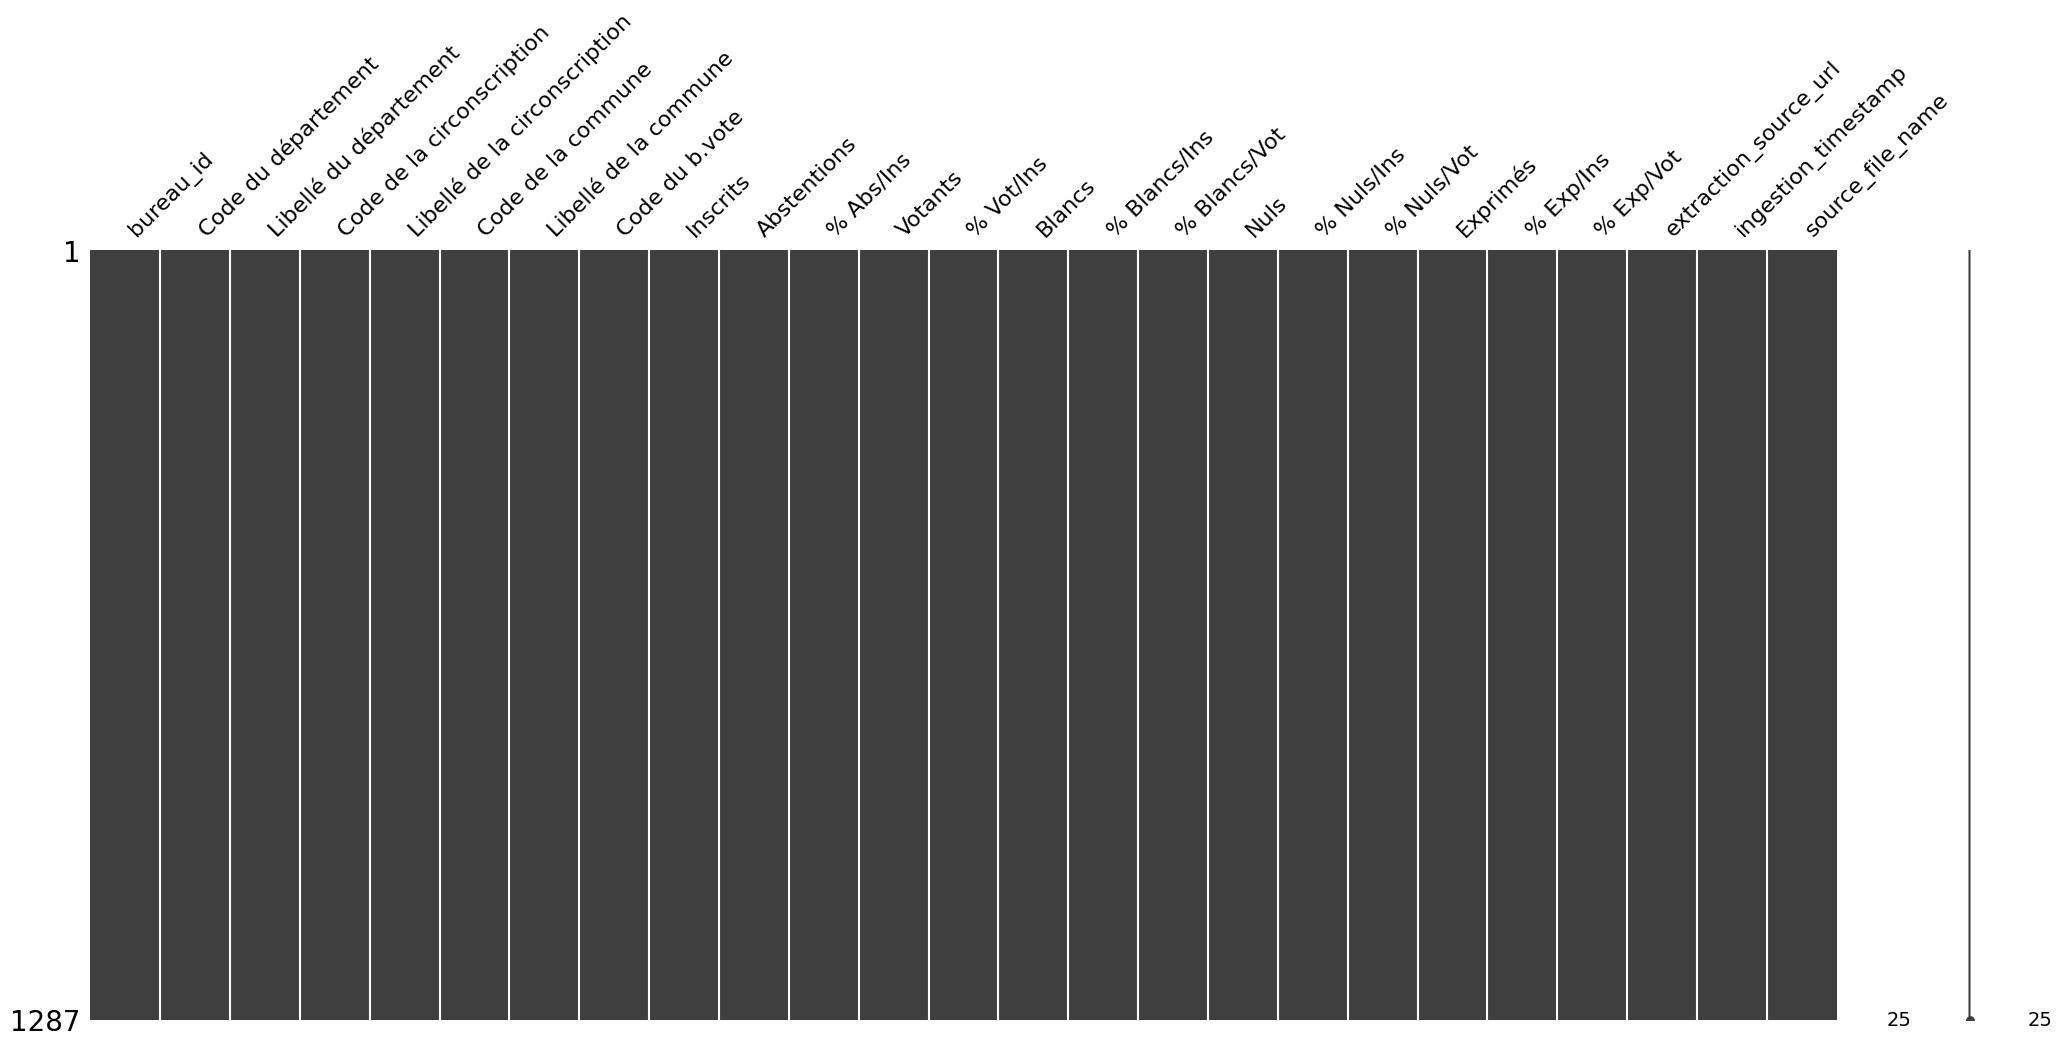

In [8]:
import missingno as msno

name = "df_bureau"
print(f"### Missingno pour {name} ###\n")
msno.matrix(df_bureau)


In [9]:
unique_counts = df_candidate.nunique(dropna=False).reset_index()
unique_counts.columns = ["column", "unique_count"]
display(unique_counts)


,column,unique_count
0,bureau_id,1287
1,numero_panneau,11
2,sexe,2
3,nom,11
4,prenom,10
5,voix,407
6,pct_voix_ins,2717
7,pct_voix_exp,3222
8,extraction_source_url,1
9,ingestion_timestamp,1


### Missingno pour df_candidate ###



<Axes: >

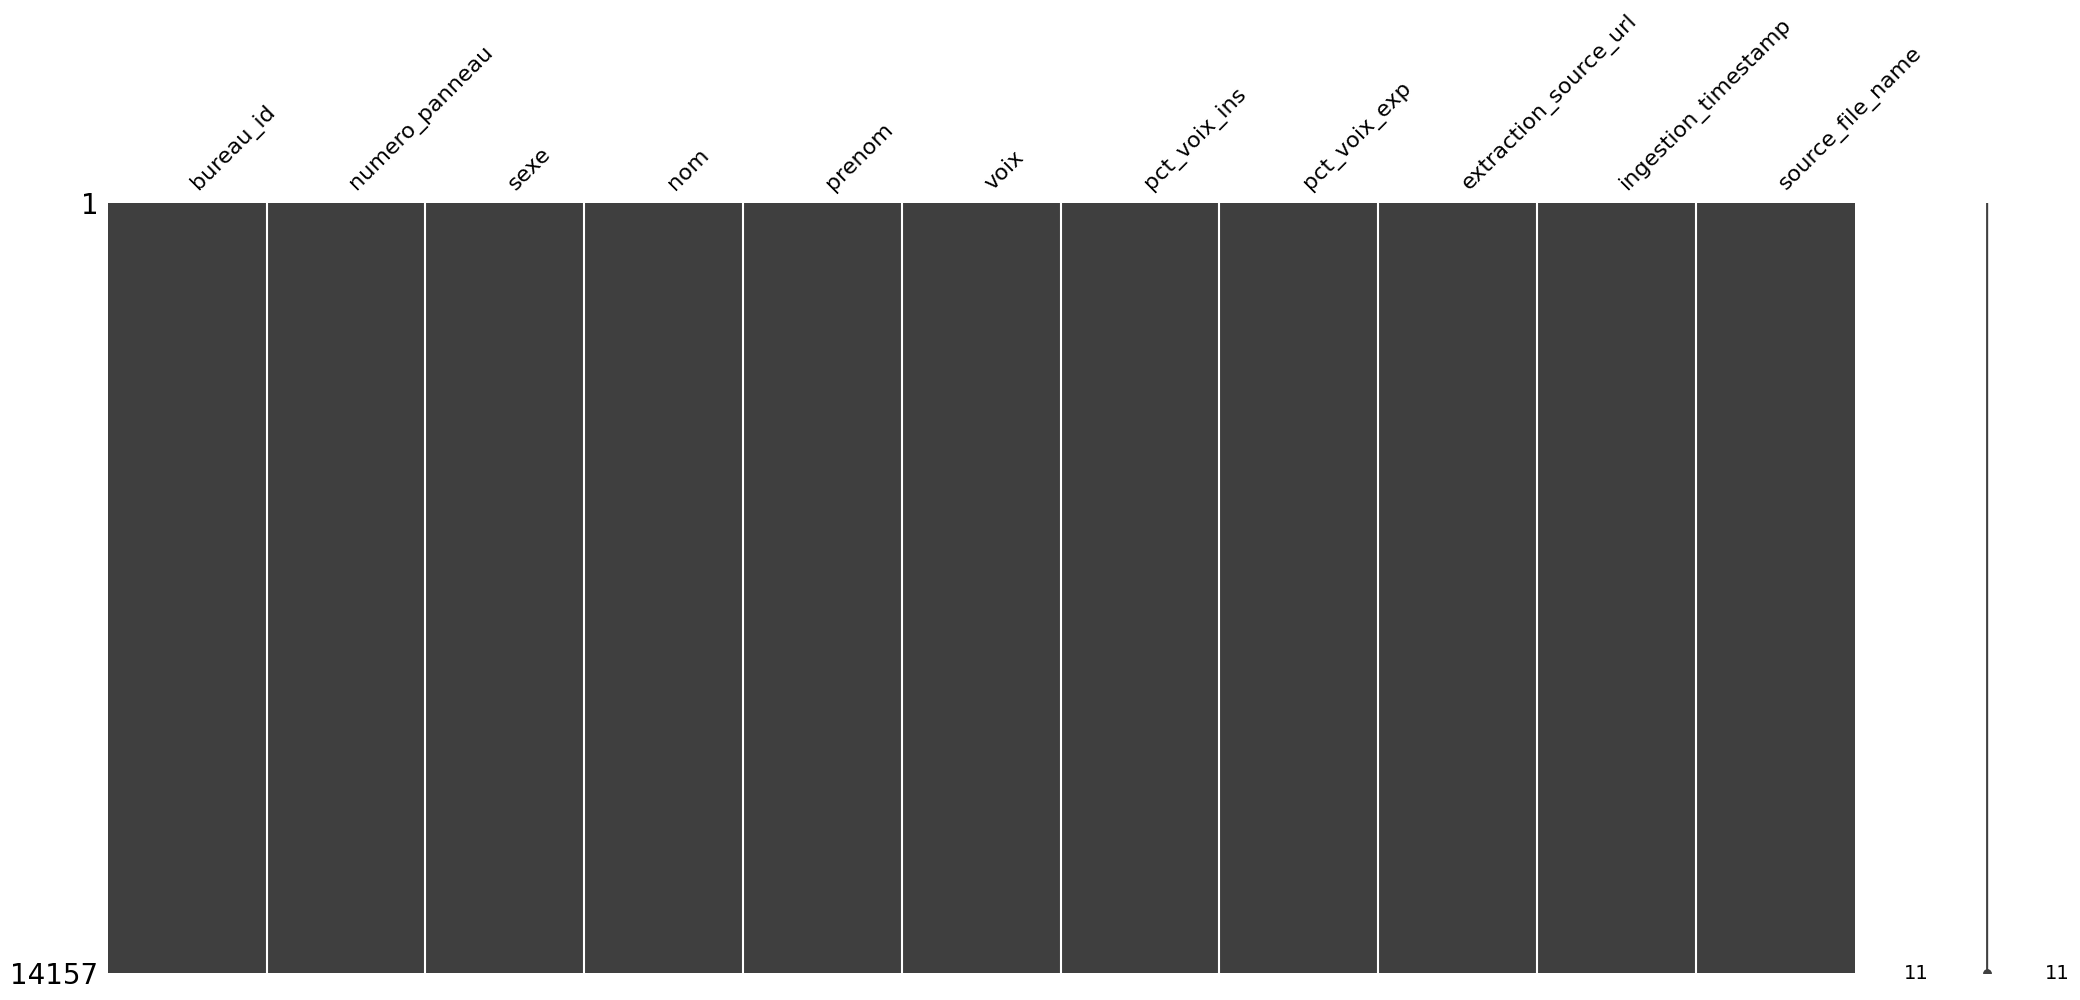

In [10]:
name = "df_candidate"
print(f"### Missingno pour {name} ###\n")
msno.matrix(df_candidate)


In [11]:
print(f"Nombre de lignes : {df_candidate.shape[0]}")
print(f"Nombre de colonnes : {df_candidate.shape[1]}")


Nombre de lignes : 14157
Nombre de colonnes : 11


In [12]:
print(f"### Statistiques descriptives pour {name} ###\n")
display(df_candidate.describe(include='all'))

### Statistiques descriptives pour df_candidate ###



,bureau_id,numero_panneau,sexe,nom,prenom,voix,pct_voix_ins,pct_voix_exp,extraction_source_url,ingestion_timestamp,source_file_name
count,14157,14157,14157,14157,14157,14157,14157,14157,14157,14157,14157
unique,1287,11,2,11,10,407,2717,3222,1,1,1
top,69_08_001_0001,1,M,DUPONT-AIGNAN,François,2,"0,00","0,00",https://www.data.gouv.fr/api/1/datasets/r/8fdb...,2026-03-18T14:25:34.183485,2017_burvot_t1_france_entiere.txt
freq,11,1287,11583,1287,2574,822,664,664,14157,14157,14157


In [13]:
print(f"### Nombre de valeurs manquantes pour {name} ###\n")
display(df_candidate.isnull().sum())

### Nombre de valeurs manquantes pour df_candidate ###



bureau_id                0
numero_panneau           0
sexe                     0
nom                      0
prenom                   0
voix                     0
pct_voix_ins             0
pct_voix_exp             0
extraction_source_url    0
ingestion_timestamp      0
source_file_name         0
dtype: int64

In [14]:
# Le pourcentage de valeur manquante de chaque colonnes
print(f"### Pourcentage de valeurs manquantes pour {name} ###\n")
display((df_candidate.isnull().sum() / len(df_candidate)) * 100)

### Pourcentage de valeurs manquantes pour df_candidate ###



bureau_id                0.0
numero_panneau           0.0
sexe                     0.0
nom                      0.0
prenom                   0.0
voix                     0.0
pct_voix_ins             0.0
pct_voix_exp             0.0
extraction_source_url    0.0
ingestion_timestamp      0.0
source_file_name         0.0
dtype: float64